Fingerprinting

This workbook uses a IDL_python bridge to run fingerprinting analysis on seasonal runoff data across New Zealand. It defines functions which read previously created runoff datafiles and setup the data_obs, data_scen, and noise vectors. These vectors are then input into Daithi Stone's gendetec IDL code which returns the regression coefficients for the multiple linear regression problem as follows: data_obs = beta_est * data_scen + residual. 

Results are saved in ~/figures/fingerprinting/beta_est/ if using a single truncation and ""/scan_beta_est/ if depicting a range of truncation options. 

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from functools import reduce
import matplotlib.pyplot as plt
from idlpy import *
from scipy import stats
import statsmodels.api as sm


import seaborn as sns
import cartopy.crs as ccrs

IDL 8.7.2 (linux x86_64 m64).
(c) 2019, Harris Geospatial Solutions, Inc.

A new version is available: IDL 8.9
https://www.l3harrisgeospatial.com/Product-Downloads/
 
Licensed for use by: NIWA - National Institute of Water and Atmospheric Research Ltd - Ashley
License: 229483-BUF
Expiration date: 31-Mar-2024


In [2]:
def get_obs_data(season, mem, resample_interval,norm_method):
    
    if season == 'concatenated':
        season_list = []
        for season in ['winter','spring','summer','autumn']:

            if norm_method == 'qmap':
                season_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/tasmax/seasonal/ECHAM5_all_'+season+'_tasmax_gaussian_ens'+mem+'.nc')
            elif norm_method == 'lmr':
                season_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/local_mean_removed/tasmax/seasonal/ECHAM5_all_'+season+'_tasmax_LMR_ens'+mem+'.nc')
            elif norm_method == 'none':
                season_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/raw/tasmax/seasonal/ECHAM5_all_'+season+'_tasmax_ens'+mem+'.nc')

            if resample_interval != 'annual':
                season_da = season_da.resample(time=resample_interval).mean()

            season_list.append(season_da)

        da = xr.concat(season_list,dim='time')
        da = da.sortby('time')

        da = da.stack(pixel=("lat", "lon"))
        da = da.dropna("pixel", how="all")        

        array = da.values.flatten()

        da.close()
    
    else:
        if norm_method == 'qmap':
            da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/tasmax/seasonal/ECHAM5_all_'+season+'_tasmax_gaussian_ens'+mem+'.nc')

        elif norm_method == 'lmr':
            da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/local_mean_removed/tasmax/seasonal/ECHAM5_all_'+season+'_tasmax_LMR_ens'+mem+'.nc')

        elif norm_method == 'none':
            da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/raw/tasmax/seasonal/ECHAM5_all_'+season+'_tasmax_ens'+mem+'.nc')

        if resample_interval != 'annual':
            da = da.resample(time=resample_interval).mean()

        da = da.stack(pixel=("lat", "lon"))
        da = da.dropna("pixel", how="all")        

        array = da.values.flatten()

        da.close()
    
    return(array)


In [3]:
def get_mean_and_noise(season,scen, mem, resample_interval,norm_method):
    
    # CONCATENATED SEASONS
    if season == 'concatenated':
        ens_mean_season_list = []
        for season in ['winter','spring','summer','autumn']:
            
            if norm_method == 'qmap':
                mean_for_noise = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/tasmax/seasonal/detrend_nat/ECHAM5_'+scen+'_'+season+'_tasmax_gaussian_ensMean.nc')

            elif norm_method == 'lmr':
                mean_for_noise = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/local_mean_removed/tasmax/seasonal/ECHAM5_'+scen+'_'+season+'_tasmax_LMR_ensMean.nc')

            elif norm_method == 'none':
                mean_for_noise = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/raw/tasmax/seasonal/ECHAM5_'+scen+'_'+season+'_tasmax_ensMean.nc')

            if resample_interval != 'annual':
                mean_for_noise = mean_for_noise.resample(time=resample_interval).mean()

            ens_mean_season_list.append(mean_for_noise)
            
        mean_for_noise = xr.concat(ens_mean_season_list,dim='time')
        mean_for_noise = mean_for_noise.sortby('time')
        
        noise = []
        da_list = []
        for ens_mem in range(1,51):
            
            number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)
            
            if number == mem:
                    continue
                    
            ens_mem_season_list = []
            for season in ['winter','spring','summer','autumn']:

                if norm_method == 'qmap':
                    ens_mem = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/tasmax/seasonal/detrend_nat/ECHAM5_'+scen+'_'+season+'_tasmax_gaussian_ens'+number+'.nc')
                elif norm_method == 'lmr':
                    ens_mem = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/local_mean_removed/tasmax/seasonal/ECHAM5_'+scen+'_'+season+'_tasmax_LMR_ens'+number+'.nc')
                elif norm_method == 'none':
                    ens_mem = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/raw/tasmax/seasonal/ECHAM5_'+scen+'_'+season+'_tasmax_ens'+number+'.nc')

                if resample_interval != 'annual':
                    ens_mem = ens_mem.resample(time=resample_interval).mean()

                ens_mem_season_list.append(ens_mem)
                
            mem_da = xr.concat(ens_mem_season_list,dim='time')
            mem_da = mem_da.sortby('time')
            
            diff = mem_da - mean_for_noise

            diff = diff.stack(pixel=("lat", "lon"))# Create a MultiIndex
            diff = diff.dropna("pixel", how="all")# Drop the pixels that only have NA values.

            diff_array = diff.values.flatten()
            diff.close()

            da_list.append(mem_da)
            noise.append(diff_array)
            
        mean_for_noise.close()
        
        ens_mean = sum(da_list)/len(da_list)
        ens_mean = ens_mean.stack(pixel=("lat", "lon")) # Create a MultiIndex
        ens_mean = ens_mean.dropna("pixel", how="all") # Drop the pixels that only have NA values.

        ens_mean_array = ens_mean.values.flatten()

        ens_mean.close()
         
    # SEASONAL
    else:
        if norm_method == 'qmap':
            if scen == 'all':
                mean_for_noise = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/tasmax/seasonal/ECHAM5_'+scen+'_'+season+'_tasmax_gaussian_ensMean.nc')
            else:
                mean_for_noise = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/tasmax/seasonal/detrend_nat/ECHAM5_'+scen+'_'+season+'_tasmax_gaussian_ensMean.nc')

        elif norm_method == 'lmr':
            mean_for_noise = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/local_mean_removed/tasmax/seasonal/ECHAM5_'+scen+'_'+season+'_tasmax_LMR_ensMean.nc')

        elif norm_method == 'none':
            mean_for_noise = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/raw/tasmax/seasonal/ECHAM5_'+scen+'_'+season+'_tasmax_ensMean.nc')

        if resample_interval != 'annual':
            mean_for_noise = mean_for_noise.resample(time=resample_interval).mean()

        noise = []
        da_list = []
        for ens_mem in range(1,51):
            number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)

            if number == mem:
                continue

            if norm_method == 'qmap':
                if scen == 'all':
                    mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/tasmax/seasonal/ECHAM5_'+scen+'_'+season+'_tasmax_gaussian_ens'+number+'.nc')
                else:
                    mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/tasmax/seasonal/detrend_nat/ECHAM5_'+scen+'_'+season+'_tasmax_gaussian_ens'+number+'.nc')

            elif norm_method == 'lmr':
                mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/local_mean_removed/tasmax/seasonal/ECHAM5_'+scen+'_'+season+'_tasmax_LMR_ens'+number+'.nc')

            elif norm_method == 'none':
                mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/raw/tasmax/seasonal/ECHAM5_'+scen+'_'+season+'_tasmax_ens'+number+'.nc')

            if resample_interval != 'annual':
                mem_da = mem_da.resample(time=resample_interval).mean()

            diff = mem_da - mean_for_noise

            diff = diff.stack(pixel=("lat", "lon"))# Create a MultiIndex
            diff = diff.dropna("pixel", how="all")# Drop the pixels that only have NA values.

            diff_array = diff.values.flatten()
            diff.close()

            da_list.append(mem_da)
            noise.append(diff_array)

        mean_for_noise.close()

        ens_mean = sum(da_list)/len(da_list)
        ens_mean = ens_mean.stack(pixel=("lat", "lon")) # Create a MultiIndex
        ens_mean = ens_mean.dropna("pixel", how="all") # Drop the pixels that only have NA values.

        ens_mean_array = ens_mean.values.flatten()

        ens_mean.close()
    
    return((ens_mean_array, np.array(noise)))



In [4]:
'''
Create indivual and ensemble summary seasonal perfect model testing plots
'''

seasons = ['summer','autumn','winter','spring']

for resample_interval in ['10Y','5Y']:#,'annual']:

    ensemble_member = []
    ant_upper = []
    ant_lower = []
    ant_best = []
    nat_upper = []
    nat_lower = []
    nat_best = []
    season = []
    for ens_mem in range(1,51):

        number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)

        fig,axs = plt.subplots(2,2, figsize=(12,10))#,sharey=True)
        axs = axs.flatten()

        for i,s in enumerate(seasons):    

            IDL.retall

            all_ens_mean,noise_all = get_mean_and_noise(s,'all',number,resample_interval,'qmap')
            nat_ens_mean,noise_nat = get_mean_and_noise(s,'nat',number,resample_interval,'qmap')

            data_obs = get_obs_data(s, number, resample_interval,'qmap')

            data_scen = np.array([all_ens_mean,nat_ens_mean])

            # double noise
            #data_noise_1 = np.concatenate((noise_all,noise_nat))
            #data_noise_2 = np.concatenate((noise_all,noise_nat))
            
            data_noise_1 = np.concatenate((noise_all[:24],noise_nat[:25]))
            data_noise_2 = np.concatenate((noise_all[24:],noise_nat[25:]))
            
            trunc = np.array([i for i in range(3,48)])
            #trunc = np.array([i for i in range(3,96)])

            IDL.data_obs = data_obs
            IDL.data_scen = data_scen
            IDL.data_noise_1 = data_noise_1
            IDL.data_noise_2 = data_noise_2
            IDL.trunc = trunc
            IDL.scan_beta_est = []
            IDL.scan_p_resid = []
            IDL.scan_resid_sumsq = []
            IDL.p_resid = []
            IDL.resid_sumsq = []
            IDL.noise_singval = []
            IDL.z_best = []

            IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, scan_resid_sumsq=scan_resid_sumsq, \
                    data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc, scan_beta_est=scan_beta_est,\
                    scan_p_resid=scan_p_resid,noise_singval=noise_singval,z_best=z_best")

            beta_est = IDL.beta_est
            scan_beta_est = IDL.scan_beta_est
            scan_p_resid = IDL.scan_p_resid
            scan_resid_sumsq = IDL.scan_resid_sumsq
            noise_singval = IDL.noise_singval
            z_best = IDL.z_best

            for j in range(len(scan_beta_est)):

                beta_est = scan_beta_est[j]

                best_1,low_1,up_1 = beta_est[0][0],beta_est[1][0],beta_est[2][0]
                best_2,low_2,up_2 = beta_est[0][1],beta_est[1][1],beta_est[2][1]

                axs[i].scatter([j+3]*3,[low_2,best_2,up_2],c='blue',alpha=0.7,label='nat' if j == 0 else '')
                axs[i].scatter([j+3]*3,[low_1,best_1,up_1],c='red',label='ant' if j == 0 else '')

                axs[i].vlines(j+3,low_2,up_2,colors=['blue'])
                axs[i].vlines(j+3,low_1,up_1,colors=['red'])
                
                axs[i].axhline(0,-0.5,1.5)
                axs[i].axhline(1,-0.5,1.5)
                
            t = 36
            ensemble_member.append(number)
            ant_upper.append(scan_beta_est[t-3][2][0])
            ant_lower.append(scan_beta_est[t-3][1][0])
            ant_best.append(scan_beta_est[t-3][0][0])
            nat_upper.append(scan_beta_est[t-3][2][1])
            nat_lower.append(scan_beta_est[t-3][1][1])
            nat_best.append(scan_beta_est[t-3][0][1])
            season.append(s)

            axs[i].set_title(s)

            axs[i].legend()
            #axs[i].set_ylim(-4,5)

        plt.savefig('/nesi/project/niwa00015/queenle/plots/perfect_model/ECHAM5/tasmax/qmap/seasonal/'+resample_interval+'/detrend_nat_trend_all/' + 'PM_ens_' + number + '.png')

        plt.close(fig)
        
    df = pd.DataFrame({'ensemble_member':ensemble_member,
                      'season':season,
                      'ant_upper':ant_upper,
                      'ant_lower':ant_lower,
                      'ant_best':ant_best,
                      'nat_upper':nat_upper,
                      'nat_lower':nat_lower,
                      'nat_best':nat_best})

    for sort_type in ['nat_best','ant_best']:
        
        fig,axs = plt.subplots(2,2, figsize=(12,10))
        axs = axs.flatten()
        
        for i,s in enumerate(seasons):
            
            sorted_df = df.loc[df['season'] == s].sort_values(by=sort_type)
            
            axs[i].scatter([i for i in range(len(sorted_df.nat_upper))],sorted_df.nat_upper,c='blue',label='nat')
            axs[i].scatter([i for i in range(len(sorted_df.nat_lower))],sorted_df.nat_lower,c='blue',label='')
            axs[i].scatter([i for i in range(len(sorted_df.nat_best))],sorted_df.nat_best,c='blue',label='')

            axs[i].scatter([i for i in range(len(sorted_df.ant_upper))],sorted_df.ant_upper,c='red',label='ant')
            axs[i].scatter([i for i in range(len(sorted_df.ant_lower))],sorted_df.ant_lower,c='red',label='')
            axs[i].scatter([i for i in range(len(sorted_df.ant_best))],sorted_df.ant_best,c='red',label='')

            axs[i].vlines([i for i in range(len(sorted_df.nat_lower))],sorted_df.nat_lower,sorted_df.nat_upper,colors=['blue'],label='')
            axs[i].vlines([i for i in range(len(sorted_df.ant_lower))],sorted_df.ant_lower,sorted_df.ant_upper,colors=['red'],label='')

            del sorted_df
            
            axs[i].axhline(0,-0.5,1.5)
            axs[i].axhline(1,-0.5,1.5)

            axs[i].set_title(s + ', trunc = ' + str(t))

            axs[i].legend()
            
            #axs[i].set_ylim(-2,3)

        
        
        plt.savefig('/nesi/project/niwa00015/queenle/plots/perfect_model/ECHAM5/tasmax/qmap/seasonal/' + resample_interval + '/detrend_nat_trend_all/' + 'PM_ensemble_summary_'+sort_type+'_sort.png')

        plt.close(fig)
        
    del df

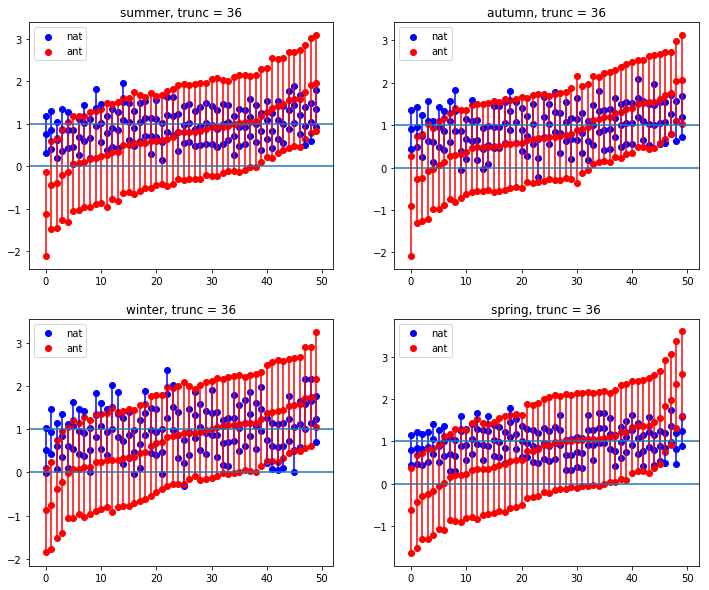

In [5]:
'''
Write ensemble summary csv files
'''

seasons = ['summer','autumn','winter','spring']

for resample_interval in ['annual','10Y','5Y']:#'annual',

    ensemble_member = []
    ant_upper = []
    ant_lower = []
    ant_best = []
    nat_upper = []
    nat_lower = []
    nat_best = []
    season = []
    for ens_mem in range(1,51):

        number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)

        for i,s in enumerate(seasons):    

            IDL.retall

            all_ens_mean,noise_all = get_mean_and_noise(s,'all',number,resample_interval,'qmap')
            nat_ens_mean,noise_nat = get_mean_and_noise(s,'nat',number,resample_interval,'qmap')

            data_obs = get_obs_data(s, number, resample_interval,'qmap')

            data_scen = np.array([all_ens_mean,nat_ens_mean])

            data_noise_1 = np.concatenate((noise_all[:24],noise_nat[:25]))
            data_noise_2 = np.concatenate((noise_all[24:],noise_nat[25:]))
            
            trunc = 36

            IDL.data_obs = data_obs
            IDL.data_scen = data_scen
            IDL.data_noise_1 = data_noise_1
            IDL.data_noise_2 = data_noise_2
            IDL.trunc = trunc

            IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, \
                    data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc")

            beta_est = IDL.beta_est

            ensemble_member.append(number)
            ant_upper.append(beta_est[2][0])
            ant_lower.append(beta_est[1][0])
            ant_best.append(beta_est[0][0])
            nat_upper.append(beta_est[2][1])
            nat_lower.append(beta_est[1][1])
            nat_best.append(beta_est[0][1])
            season.append(s)
        
    df = pd.DataFrame({'ensemble_member':ensemble_member,
                      'season':season,
                      'ant_upper':ant_upper,
                      'ant_lower':ant_lower,
                      'ant_best':ant_best,
                      'nat_upper':nat_upper,
                      'nat_lower':nat_lower,
                      'nat_best':nat_best})

    df.to_csv("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/summary_csv/detrend_nat_trend_all/tasmax_" +resample_interval + "_trunc_" + str(trunc) + ".csv")
    
    del df

In [12]:
df

,ensemble_member,season,ant_upper,ant_lower,ant_best,nat_upper,nat_lower,nat_best
0,01,summer,1.638015,-0.428148,0.604933,1.580710,0.772830,1.176770
1,01,autumn,1.698819,-0.314611,0.692104,1.296036,0.415339,0.855688
2,01,winter,2.077538,-0.053781,1.011879,1.419939,0.507361,0.963650
3,01,spring,2.195701,-0.040548,1.077577,1.105544,0.411283,0.758413
4,02,summer,2.033917,-0.185929,0.923994,1.378337,0.551477,0.964907
...,...,...,...,...,...,...,...,...
195,49,spring,2.394183,0.208460,1.301321,1.626859,0.931634,1.279246
196,50,summer,1.302604,-0.820742,0.240931,1.125052,0.314578,0.719815
197,50,autumn,1.810682,-0.166039,0.822321,1.306219,0.501441,0.903830
198,50,winter,2.558869,0.435498,1.497184,1.691412,0.741838,1.216625


In [13]:
df.to_csv("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/summary_csv/tasmax_" +resample_interval + "_trunc_" + str(trunc) + ".csv")
